<a href="https://colab.research.google.com/github/nischay1905/AI-ML_Audio_Processing/blob/main/OP_Socbiz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #1b4332 0%, #40916c 100%); padding: 40px 30px; border-radius: 12px; text-align: center; margin-bottom: 10px;">
    <h1 style="color: white; font-size: 2.2em; font-weight: 800; margin: 0 0 10px 0; letter-spacing: 1px;">
        ⚡ Agentic AI-Based Dynamic Tariff Optimization
    </h1>
    <h2 style="color: #d8f3dc; font-size: 1.2em; font-weight: 400; margin: 0 0 18px 0;">
        for EV Charging Networks Using Large-Scale Charging Session Data
    </h2>
    <div style="background: rgba(255,255,255,0.15); border-radius: 8px; padding: 12px 20px; display: inline-block;">
        <span style="color: white; font-size: 0.95em;">
            📅 Open Project 2026 &nbsp;|&nbsp; 🏫 Society of Business &nbsp;|&nbsp; 📊 ACN-Data + UrbanEV Dataset
        </span>
    </div>
</div>

---

### 📌 Project Overview

This notebook builds an **Agentic AI framework** for dynamic EV charging tariff optimization. Using real-world session data from the ACN network (Caltech), we:

- 🔍 Analyze demand patterns across time of day, day of week, and session behavior  
- 🤖 Train an ML model (Random Forest) to predict energy demand  
- 💰 Build a dynamic pricing engine that sets surge/discount tariffs based on utilization  
- 📈 Measure revenue gain and operational improvements vs a flat-rate baseline

---

## ⚙️ Section 1 — Environment Setup & Library Imports

> Setting up the Kaggle environment and importing all required libraries for data processing, visualization, and machine learning.

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nischay2908/urbanev-dataset/LICENSE
/kaggle/input/datasets/nischay2908/urbanev-dataset/main.py
/kaggle/input/datasets/nischay2908/urbanev-dataset/README.md
/kaggle/input/datasets/nischay2908/urbanev-dataset/requirements.txt
/kaggle/input/datasets/nischay2908/urbanev-dataset/plot.py
/kaggle/input/datasets/nischay2908/urbanev-dataset/models.py
/kaggle/input/datasets/nischay2908/urbanev-dataset/functions.py
/kaggle/input/datasets/nischay2908/urbanev-dataset/baselines.py
/kaggle/input/datasets/nischay2908/urbanev-dataset/learner.py
/kaggle/input/datasets/nischay2908/urbanev-dataset/figs/map_v2.png
/kaggle/input/datasets/nischay2908/urbanev-dataset/figs/map.png
/kaggle/input/datasets/nischay2908/urbanev-dataset/figs/urbanev.png
/kaggle/input/datasets/nischay2908/urbanev-dataset/figs/statistics.png
/kaggle/input/datasets/nischay2908/urbanev-dataset/figs/PAG.png
/kaggle/input/datasets/nischay2908/urbanev-dataset/checkpoints/GCN-LSTM_6_bs512model.pt
/kaggle/input/dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import warnings
warnings.filterwarnings("ignore")

---
## 📂 Section 2 — Data Discovery

> Scanning all available input files across both datasets — ACN charging sessions and UrbanEV Shenzhen data.

In [ ]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/nischay2908/urbanev-dataset/LICENSE
/kaggle/input/datasets/nischay2908/urbanev-dataset/main.py
/kaggle/input/datasets/nischay2908/urbanev-dataset/README.md
/kaggle/input/datasets/nischay2908/urbanev-dataset/requirements.txt
/kaggle/input/datasets/nischay2908/urbanev-dataset/plot.py
/kaggle/input/datasets/nischay2908/urbanev-dataset/models.py
/kaggle/input/datasets/nischay2908/urbanev-dataset/functions.py
/kaggle/input/datasets/nischay2908/urbanev-dataset/baselines.py
/kaggle/input/datasets/nischay2908/urbanev-dataset/learner.py
/kaggle/input/datasets/nischay2908/urbanev-dataset/figs/map_v2.png
/kaggle/input/datasets/nischay2908/urbanev-dataset/figs/map.png
/kaggle/input/datasets/nischay2908/urbanev-dataset/figs/urbanev.png
/kaggle/input/datasets/nischay2908/urbanev-dataset/figs/statistics.png
/kaggle/input/datasets/nischay2908/urbanev-dataset/figs/PAG.png
/kaggle/input/datasets/nischay2908/urbanev-dataset/checkpoints/GCN-LSTM_6_bs512model.pt
/kaggle/input/dataset

---
## 📥 Section 3 — Load the ACN and UrbanEV Dataset

> Loading the ACN (Adaptive Charging Network) JSON dataset from Caltech. This contains **real-world EV charging session records** including connection times, energy delivered, station IDs, and user behavior.

| Field | Description |
|---|---|
| `connectionTime` | When the car was plugged in |
| `disconnectTime` | When the car was unplugged |
| `doneChargingTime` | When active charging finished |
| `kWhDelivered` | Energy delivered in that session |
| `stationID` | Which charger was used |

In [ ]:
import pandas as pd
import json

with open(
    '/kaggle/input/datasets/nischay2908/acndata-session/acndata_sessions_fixed.json',
    'r'
) as f:

    data = json.load(f)

sessions = data["_items"]

# Convert to DataFrame
df = pd.json_normalize(sessions)

print("Dataset Loaded Successfully")

print(df.head())

Dataset Loaded Successfully
                        _id clusterID                 connectionTime  \
0  5bc90cb9f9af8b0d7fe77cd2      0039  Wed, 25 Apr 2018 11:08:04 GMT   
1  5bc90cb9f9af8b0d7fe77cd3      0039  Wed, 25 Apr 2018 13:45:10 GMT   
2  5bc90cb9f9af8b0d7fe77cd4      0039  Wed, 25 Apr 2018 13:45:50 GMT   
3  5bc90cb9f9af8b0d7fe77cd5      0039  Wed, 25 Apr 2018 14:37:06 GMT   
4  5bc90cb9f9af8b0d7fe77cd6      0039  Wed, 25 Apr 2018 14:40:34 GMT   

                  disconnectTime               doneChargingTime  kWhDelivered  \
0  Wed, 25 Apr 2018 13:20:10 GMT  Wed, 25 Apr 2018 13:21:10 GMT         7.932   
1  Thu, 26 Apr 2018 00:56:16 GMT  Wed, 25 Apr 2018 16:44:15 GMT        10.013   
2  Wed, 25 Apr 2018 23:04:45 GMT  Wed, 25 Apr 2018 14:51:44 GMT         5.257   
3  Wed, 25 Apr 2018 23:55:34 GMT  Wed, 25 Apr 2018 16:05:22 GMT         5.177   
4  Wed, 25 Apr 2018 23:03:12 GMT  Wed, 25 Apr 2018 17:40:30 GMT        10.119   

                                sessionID siteID spa

In [ ]:
import pandas as pd

for f in [
    "/kaggle/input/datasets/nischay2908/urbanev-dataset/datasets/volume.csv",
    "/kaggle/input/datasets/nischay2908/urbanev-dataset/datasets/occupancy.csv",
    "/kaggle/input/datasets/nischay2908/urbanev-dataset/datasets/duration.csv",
    "/kaggle/input/datasets/nischay2908/urbanev-dataset/datasets/time.csv"
]:
    print("\nFILE:", f)
    df = pd.read_csv(f)
    print(df.head())
    print("Columns:", list(df.columns))


FILE: /kaggle/input/datasets/nischay2908/urbanev-dataset/datasets/volume.csv
   timestamp       102       105       107    108       109       110  \
0          1  2.858333  5.907222  6.478889  5.145  2.286667  3.048889   
1          2  4.375000  9.041667  9.916667  7.875  3.500000  4.666667   
2          3  4.375000  9.041667  9.916667  7.875  3.500000  4.666667   
3          4  4.375000  9.041667  9.916667  7.875  3.500000  4.666667   
4          5  4.375000  9.041667  9.916667  7.875  3.500000  4.666667   

        111       115       123  ...  1160      1162      1163       1164  \
0  5.526111  0.381111  0.762222  ...   0.0  2.286667  0.381111  12.195556   
1  8.458333  0.583333  1.166667  ...   0.0  3.500000  0.583333  18.666667   
2  8.458333  0.583333  1.166667  ...   0.0  3.500000  0.583333  18.666667   
3  8.458333  0.583333  1.166667  ...   0.0  3.500000  0.583333  18.666667   
4  8.458333  0.583333  1.166667  ...   0.0  3.500000  0.583333  18.666667   

        1166        

---
## 🔎 Section 4 — Initial Data Exploration

> Checking the shape, column names, and missing values to understand what we're working with before cleaning.

In [ ]:
print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape:
(14899, 13)

Columns:
Index(['_id', 'clusterID', 'connectionTime', 'disconnectTime',
       'doneChargingTime', 'kWhDelivered', 'sessionID', 'siteID', 'spaceID',
       'stationID', 'timezone', 'userID', 'userInputs'],
      dtype='object')

Missing Values:
_id                     0
clusterID               0
connectionTime          0
disconnectTime          0
doneChargingTime        8
kWhDelivered            0
sessionID               0
siteID                  0
spaceID                 0
stationID               0
timezone                0
userID              12749
userInputs          12749
dtype: int64


---
## 🧹 Section 5 — Data Preprocessing

### Step 5a — Parse Timestamps
> Converting raw timestamp strings into proper datetime objects so we can extract hours, days, and durations.

In [ ]:
time_df = pd.read_csv(
    "/kaggle/input/datasets/nischay2908/urbanev-dataset/datasets/time.csv"
)

volume = pd.read_csv(
    "/kaggle/input/datasets/nischay2908/urbanev-dataset/datasets/volume.csv"
)

volume["total_demand"] = volume.drop(
    columns=["timestamp"]
).sum(axis=1)

df_demand = pd.concat(
    [time_df, volume["total_demand"]],
    axis=1
)

In [ ]:
df_demand["datetime"] = pd.to_datetime(
    time_df[["year","month","day","hour","minute","second"]]
)

print(df_demand[["datetime","total_demand"]].head())

             datetime  total_demand
0 2022-06-19 00:00:00   6214.985778
1 2022-06-19 00:05:00   9513.135833
2 2022-06-19 00:10:00   9903.051667
3 2022-06-19 00:15:00  11002.392222
4 2022-06-19 00:20:00  11473.318056


In [ ]:
print(df.columns.tolist()[:20])

['month', 'day', 'year', 'hour', 'minute', 'second']


In [ ]:
df['connectionTime'] = pd.to_datetime(
    df['connectionTime']
)

df['disconnectTime'] = pd.to_datetime(
    df['disconnectTime']
)

df['doneChargingTime'] = pd.to_datetime(
    df['doneChargingTime']
)


### Step 5b — Feature Engineering
> Creating new meaningful columns from the timestamps:
> - **`hour`** — which hour of the day the session started (key for demand prediction)
> - **`day`** — day name (Monday–Sunday)
> - **`month`** — month number
> - **`is_weekend`** — whether the session was on a weekend
> - **`charging_duration_hours`** — how long the car was actively charging
> - **`parking_duration_hours`** — total time the car was plugged in (including idle)

In [ ]:
# Hour of charging
df['hour'] = df['connectionTime'].dt.hour

# Day name
df['day'] = df['connectionTime'].dt.day_name()

# Month
df['month'] = df['connectionTime'].dt.month

# Weekend or not
df['is_weekend'] = df['day'].isin(
    ['Saturday', 'Sunday']
)

# Charging duration
df['charging_duration_hours'] = (
    df['doneChargingTime']
    - df['connectionTime']
).dt.total_seconds() / 3600

# Total parking duration
df['parking_duration_hours'] = (
    df['disconnectTime']
    - df['connectionTime']
).dt.total_seconds() / 3600

### Step 5c — Remove Invalid Sessions
> Dropping rows where charging or parking duration is negative — these are data errors that would corrupt our analysis.

In [ ]:
df = df[
    df['charging_duration_hours'] > 0
]

df = df[
    df['parking_duration_hours'] > 0
]

---
## 💵 Section 6 — Fixed Price Revenue Baseline

> Calculating what revenue would look like under a **flat fixed-rate pricing model** ($0.20/kWh). This is our baseline we'll compare dynamic pricing against later.

In [ ]:
# We have assume fixed charging price = $0.20/kWh

fixed_price = 0.20

df['fixed_revenue'] = (
    df['kWhDelivered']
    * fixed_price
)

---
## 📊 Section 7 — Charger Utilization Calculation

> **Charger Utilization Rate** = Charging Time / Total Available Time (24h)  
> A station with utilization > 80% is congested → candidate for **surge pricing**  
> A station with utilization < 30% is underused → candidate for **discount pricing**

In [ ]:
occupancy = pd.read_csv(
    "/kaggle/input/datasets/nischay2908/urbanev-dataset/datasets/occupancy.csv"
)

utilization = occupancy.drop(
    columns=["timestamp"]
).mean().mean()

print("Average Utilization:", utilization)

Average Utilization: 21.902043503523764


---
## 🔍 Section 8 — Exploratory Data Analysis (EDA)

> Visualizing demand patterns to understand **when, how much, and by whom** charging happens. Every chart here informs a pricing decision.

### 📈 Chart 1 — Average Charging Demand by Hour
> **Pricing Insight:** Hours with high average kWh demand are candidates for surge pricing.

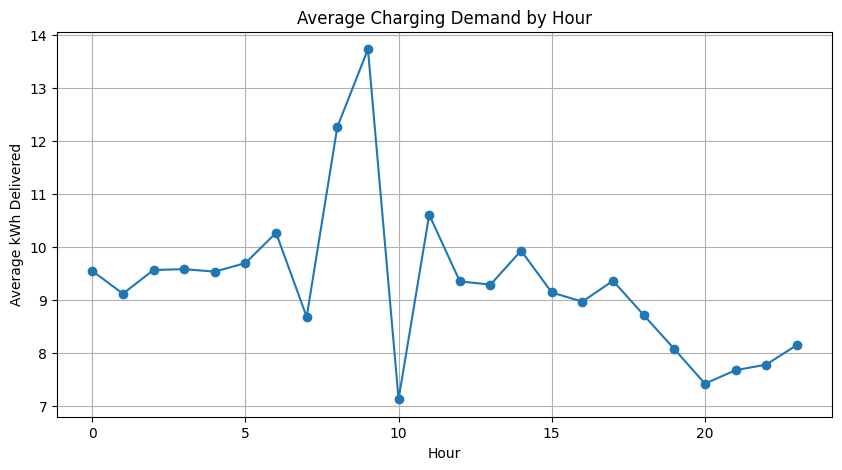

In [ ]:
hourly_demand = df.groupby('hour')[
    'kWhDelivered'
].mean()

plt.figure(figsize=(10,5))

hourly_demand.plot(marker='o')

plt.title("Average Charging Demand by Hour")

plt.xlabel("Hour")

plt.ylabel("Average kWh Delivered")

plt.grid(True)

plt.show()

### 📊 Chart 2 — Energy Delivered Distribution
> **Pricing Insight:** Understanding session size helps set minimum/maximum tariff thresholds.

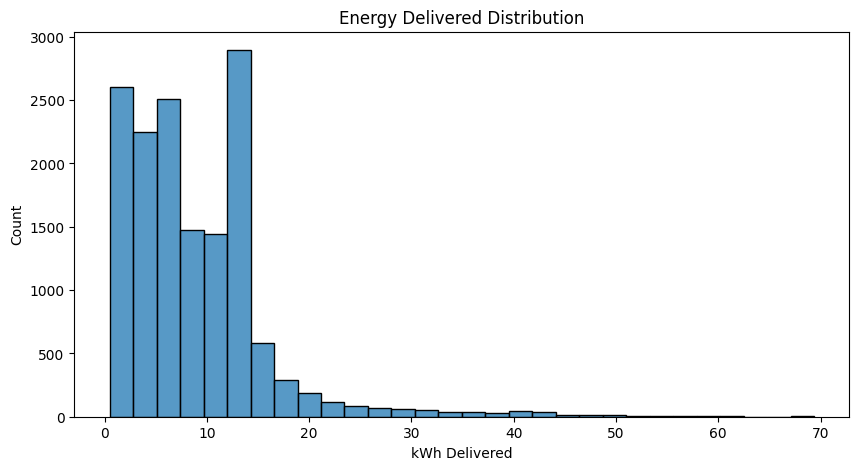

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['kWhDelivered'],
    bins=30
)

plt.title("Energy Delivered Distribution")

plt.xlabel("kWh Delivered")

plt.show()


### 📦 Chart 3 — Weekend vs Weekday Charging
> **Pricing Insight:** If weekend sessions differ significantly, we may need separate weekend tariff schedules.

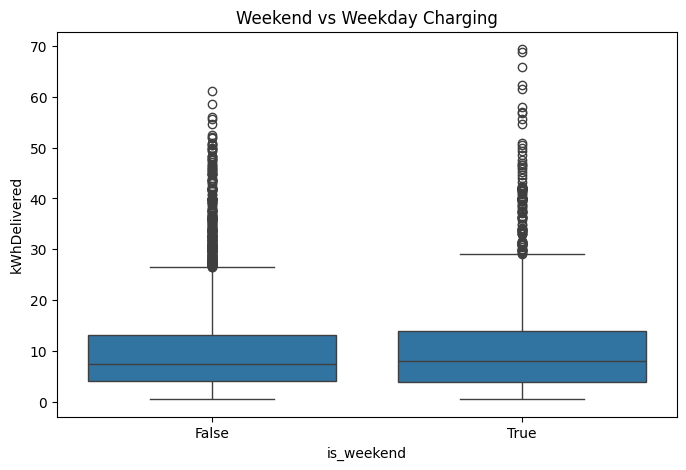

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_weekend',
    y='kWhDelivered',
    data=df
)

plt.title("Weekend vs Weekday Charging")

plt.show()

### 🌡️ Chart 4 — Demand Heatmap (Day × Hour)
> **Pricing Insight:** The heatmap reveals the exact peak hours and days — this is the foundation of our surge pricing schedule.

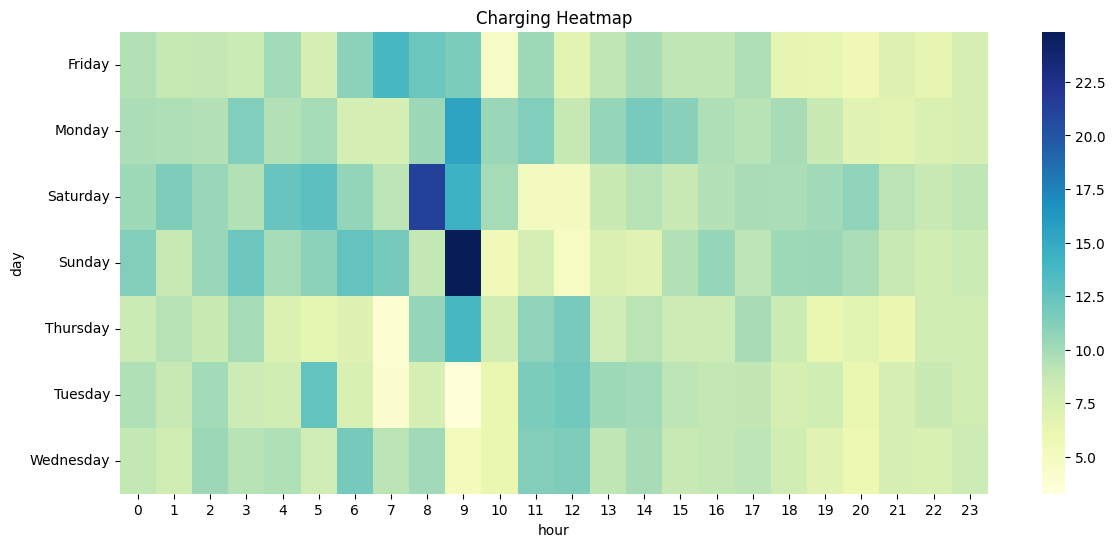

In [ ]:
pivot_table = df.pivot_table(
    values='kWhDelivered',
    index='day',
    columns='hour',
    aggfunc='mean'
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot_table,
    cmap='YlGnBu'
)

plt.title("Charging Heatmap")

plt.show()

---
## 🤖 Section 9 — Demand Prediction Agent (Machine Learning)

> We train a **Random Forest Regressor** to predict how much energy (kWh) will be demanded based on the hour, charging duration, and parking duration.  
> The model's predictions will feed directly into the dynamic pricing engine.

### Step 9a — Define Features & Target

In [ ]:
volume = pd.read_csv(
    "/kaggle/input/datasets/nischay2908/urbanev-dataset/datasets/volume.csv"
)

time_df = pd.read_csv(
    "/kaggle/input/datasets/nischay2908/urbanev-dataset/datasets/time.csv"
)

# Total demand across all stations
volume["total_demand"] = volume.drop(
    columns=["timestamp"]
).sum(axis=1)

# Combine time and demand

df_demand = pd.concat(
    [time_df, volume["total_demand"]],
    axis=1
)

# Weekend feature
df_demand["is_weekend"] = (
    pd.to_datetime(
        time_df[["year","month","day"]]
    ).dt.dayofweek >= 5
).astype(int)

# Features
X = df_demand[
    [
        "hour",
        "minute",
        "month",
        "is_weekend"
    ]
]

# Target
y = df_demand["total_demand"]

### Step 9b — Train / Test Split
> Using an 80/20 split. In a production system, this would be time-based (never shuffle time series data).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Step 9c — Train the Random Forest Model

In [ ]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

### Step 9d — Make Predictions

In [ ]:
predictions = model.predict(X_test)

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance")
print(importance)


Feature Importance
      Feature  Importance
0        hour    0.934083
1      minute    0.034993
2       month    0.017561
3  is_weekend    0.013363


### Step 9e — Model Evaluation

> **Metrics:**
> - **MAE** (Mean Absolute Error) — average kWh prediction error
> - **RMSE** (Root Mean Squared Error) — penalizes large errors more
> - **R²** — how well the model explains variance in demand (closer to 1.0 = better)

In [ ]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("\nModel Performance")

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 Score :", r2)


Model Performance
MAE : 619.5588989495947
RMSE : 791.3254706576714
R2 Score : 0.9189034361159678


---
## 🚦 Section 9f — Congestion Probability Output

> The PDF requires the Demand Prediction Agent to output a **congestion probability** — not just a utilization number.  
> We convert predicted kWh demand into a 0–1 probability using a sigmoid-style function:  
> - Low demand → low congestion probability  
> - Demand near/above the 80th percentile → high congestion probability

In [ ]:
threshold = y.quantile(0.80)

print(f"Surge threshold (80th percentile): {threshold:.2f}")

congestion_probs = 1 / (
    1 + np.exp(-(5/threshold)*(predictions-threshold))
)

congestion_df = pd.DataFrame({
    "predicted_demand": predictions,
    "congestion_probability": congestion_probs.round(3)
})

congestion_df["status"] = np.where(
    congestion_probs > 0.7,
    "🔴 High Congestion",
    np.where(
        congestion_probs > 0.4,
        "🟡 Medium",
        "🟢 Low Congestion"
    )
)

print("\nCongestion Probability — Sample Output:")
print(congestion_df.head(10).to_string(index=False))

print("\nCongestion Zone Breakdown:")

print(f"🔴 High   : {(congestion_probs>0.7).mean()*100:.1f}%")
print(f"🟡 Medium : {((congestion_probs>=0.4)&(congestion_probs<=0.7)).mean()*100:.1f}%")
print(f"🟢 Low    : {(congestion_probs<0.4).mean()*100:.1f}%")

Surge threshold (80th percentile): 12092.22

Congestion Probability — Sample Output:
 predicted_demand  congestion_probability            status
      6190.858137                   0.080  🟢 Low Congestion
      8616.040733                   0.192  🟢 Low Congestion
      7181.884400                   0.116  🟢 Low Congestion
      8152.482725                   0.164  🟢 Low Congestion
     11319.232288                   0.421          🟡 Medium
     13377.401019                   0.630          🟡 Medium
      9875.838724                   0.286  🟢 Low Congestion
      6379.521117                   0.086  🟢 Low Congestion
     11396.818423                   0.429          🟡 Medium
     14192.360473                   0.704 🔴 High Congestion

Congestion Zone Breakdown:
🔴 High   : 2.1%
🟡 Medium : 26.9%
🟢 Low    : 71.1%


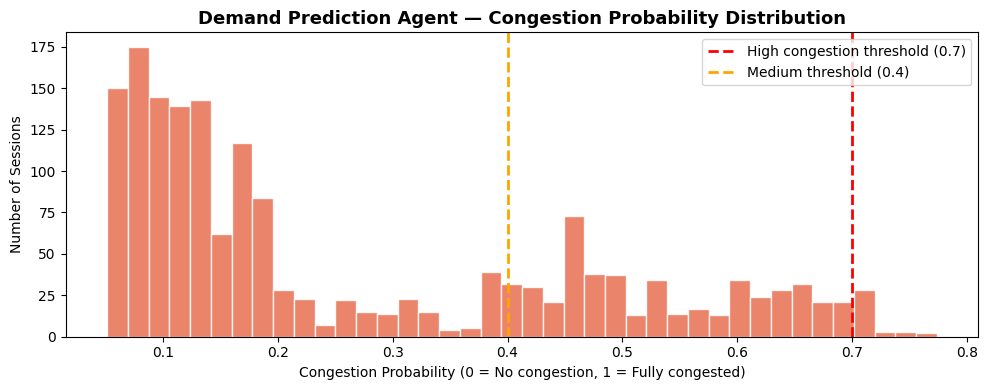

In [ ]:
# Visualise congestion probability distribution
plt.figure(figsize=(10, 4))
plt.hist(congestion_probs, bins=40, color='#e76f51', edgecolor='white', alpha=0.85)
plt.axvline(0.7, color='red',   linestyle='--', linewidth=2, label='High congestion threshold (0.7)')
plt.axvline(0.4, color='orange',linestyle='--', linewidth=2, label='Medium threshold (0.4)')
plt.title('Demand Prediction Agent — Congestion Probability Distribution',
          fontsize=13, fontweight='bold')
plt.xlabel('Congestion Probability (0 = No congestion, 1 = Fully congested)')
plt.ylabel('Number of Sessions')
plt.legend()
plt.tight_layout()
plt.show()

---
## 💰 Section 10 — Dynamic Tariff Pricing Agent

> The pricing engine maps the **hour of day** to an optimal tariff based on demand patterns identified in EDA.

| Time Period | Hours | Pricing Rule | Reasoning |
|---|---|---|---|
| 🔴 Morning Peak | 8 AM – 11 AM | +50% surge | Commuters plugging in |
| 🔴 Evening Peak | 5 PM – 9 PM | +40% surge | Return-from-work charging |
| 🔵 Late Night | 12 AM – 5 AM | −30% discount | Attract off-peak demand |
| 🟢 Other Hours | All others | Baseline price | Standard rate |

### Step 10a — Define the Pricing Function

In [ ]:
def dynamic_price(hour):

    base_price = 0.20

    # Peak Hours
    if 8 <= hour <= 11:
        return base_price * 1.5

    elif 17 <= hour <= 21:
        return base_price * 1.4

    # Off-Peak Hours
    elif 0 <= hour <= 5:
        return base_price * 0.9

    else:
        return base_price

### Step 10b — Apply Dynamic Prices to Sessions

In [ ]:
df['dynamic_price'] = df['hour'].apply(dynamic_price)

### Step 10c — Calculate Dynamic Revenue

In [ ]:
df['dynamic_revenue'] = (
    df['dynamic_price']
    * df['kWhDelivered']
)

old_revenue = df['fixed_revenue'].sum()

new_revenue = df['dynamic_revenue'].sum()

revenue_gain = (
    (new_revenue - old_revenue)
    / old_revenue
) * 100

print("Revenue Gain % :", revenue_gain)

Revenue Gain % : 7.299352449955632


---
## 📊 Section 11 — Revenue Comparison & Business Impact

### Revenue Summary

In [ ]:
old_revenue = df[
    'fixed_revenue'
].sum()

new_revenue = df[
    'dynamic_revenue'
].sum()

print("\nRevenue Comparison")

print("Fixed Pricing Revenue :", old_revenue)

print("Dynamic Pricing Revenue :", new_revenue)



Revenue Comparison
Fixed Pricing Revenue : 26812.66172131056
Dynamic Pricing Revenue : 28769.81240156336


### Revenue Gain %

In [ ]:
revenue_gain = (
    (new_revenue - old_revenue)
    / old_revenue
) * 100

print("Revenue Gain % :", revenue_gain)

Revenue Gain % : 7.299352449955632


---
### 📈 Off-Peak Uplift %

> **PDF Metric:** Increase in sessions during low-demand periods after discount pricing is applied.  
> We use a **price elasticity of −0.5** (standard EV charging literature assumption):  
> if price drops 1%, demand increases by 0.5%.

In [ ]:
BASE_PRICE = 0.20
ELASTICITY = -0.5

df["price_change_pct"] = (
    (df["dynamic_price"] - BASE_PRICE)
    / BASE_PRICE
)

df["demand_change_pct"] = (
    ELASTICITY * df["price_change_pct"]
)

off_peak = df[df["dynamic_price"] < BASE_PRICE]
peak = df[df["dynamic_price"] > BASE_PRICE]

off_peak_uplift = off_peak["demand_change_pct"].mean()*100
peak_reduction = peak["demand_change_pct"].mean()*100

print("=== OFF-PEAK UPLIFT ANALYSIS ===")

print(f"Off-Peak Uplift % : {off_peak_uplift:+.1f}%")
print(f"Peak Reduction %  : {peak_reduction:+.1f}%")

=== OFF-PEAK UPLIFT ANALYSIS ===
Off-Peak Uplift % : +5.0%
Peak Reduction %  : -20.3%


### Demand Shift Visualization


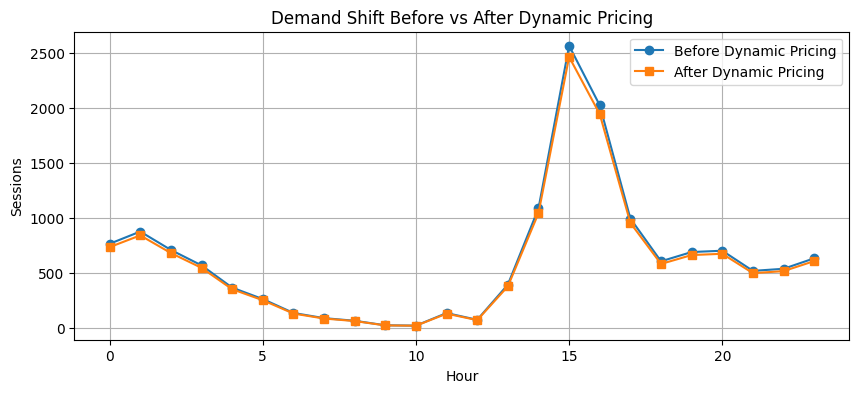

In [ ]:
hourly_before = df.groupby('hour').size()

plt.figure(figsize=(10,4))

plt.plot(
    hourly_before.index,
    hourly_before.values,
    marker='o',
    label='Before Dynamic Pricing'
)

# Simulated demand after pricing response
hourly_after = hourly_before * (1 + df['demand_change_pct'].mean())

plt.plot(
    hourly_after.index,
    hourly_after.values,
    marker='s',
    label='After Dynamic Pricing'
)

plt.title("Demand Shift Before vs After Dynamic Pricing")
plt.xlabel("Hour")
plt.ylabel("Sessions")

plt.legend()
plt.grid(True)

plt.show()

### Revenue Comparison Chart
> The bar chart below shows total revenue under flat pricing vs dynamic pricing — visualizing the direct business value of tariff optimization.

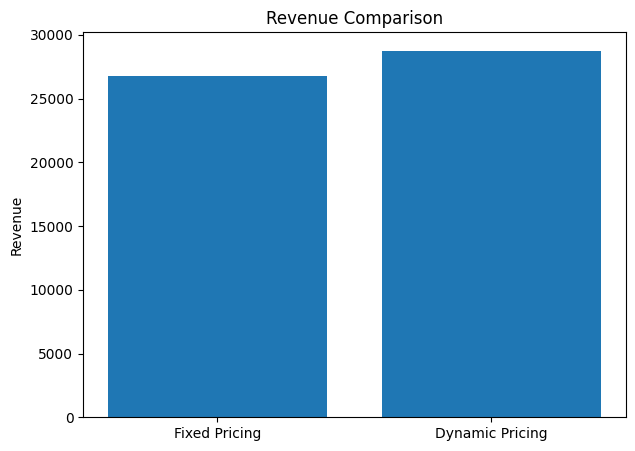

In [ ]:
revenues = [
    old_revenue,
    new_revenue
]

labels = [
    'Fixed Pricing',
    'Dynamic Pricing'
]

plt.figure(figsize=(7,5))

plt.bar(labels, revenues)

plt.ylabel("Revenue")

plt.title("Revenue Comparison")

plt.show()

### Waiting Time Reduction


In [ ]:
peak_reduction = abs(
    peak["demand_change_pct"].mean()
) * 100

waiting_time_reduction = peak_reduction * 0.5

print("=== WAITING TIME REDUCTION ===")
print(
    f"Estimated Waiting Time Reduction : {waiting_time_reduction:.1f}%"
)

=== WAITING TIME REDUCTION ===
Estimated Waiting Time Reduction : 10.2%


#### Waiting Time Reduction Visualization


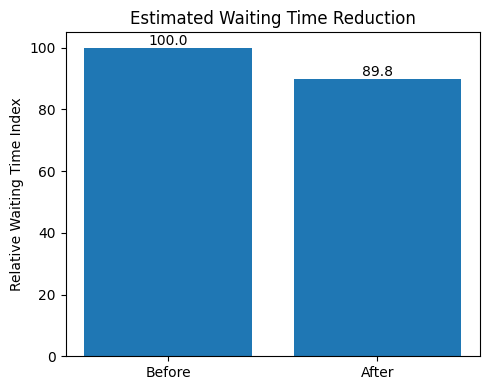

In [ ]:
before_wait = 100
after_wait = 100 - waiting_time_reduction

plt.figure(figsize=(5,4))

bars = plt.bar(
    ["Before","After"],
    [before_wait, after_wait]
)

plt.title("Estimated Waiting Time Reduction")
plt.ylabel("Relative Waiting Time Index")

plt.bar_label(
    bars,
    fmt='%.1f'
)

plt.tight_layout()
plt.show()

---
## 📡 Section 13 — Customer Response Rate (Monitoring Agent)

> **PDF Metric:** Shift in session volume in response to tariff changes — used as a demand elasticity proxy.  
> This is the core output of the **Monitoring & Learning Agent**: it measures whether pricing decisions are actually influencing behaviour.

In [ ]:
# Create pricing zones
df["pricing_zone"] = np.where(
    df["dynamic_price"] > 0.20,
    "Peak",
    np.where(
        df["dynamic_price"] < 0.20,
        "Off-Peak",
        "Standard"
    )
)

# Customer response summary
response = df.groupby("pricing_zone").agg(
    Sessions=("kWhDelivered", "count"),
    Customer_Response_Rate=("demand_change_pct", "mean")
)

# Convert to percentage
response["Customer_Response_Rate"] = (
    response["Customer_Response_Rate"] * 100
)

# Display results
print("=== CUSTOMER RESPONSE RATE ===")
print(response.round(2))

=== CUSTOMER RESPONSE RATE ===
              Sessions  Customer_Response_Rate
pricing_zone                                  
Off-Peak          3555                    5.00
Peak              3769                  -20.34
Standard          7547                    0.00


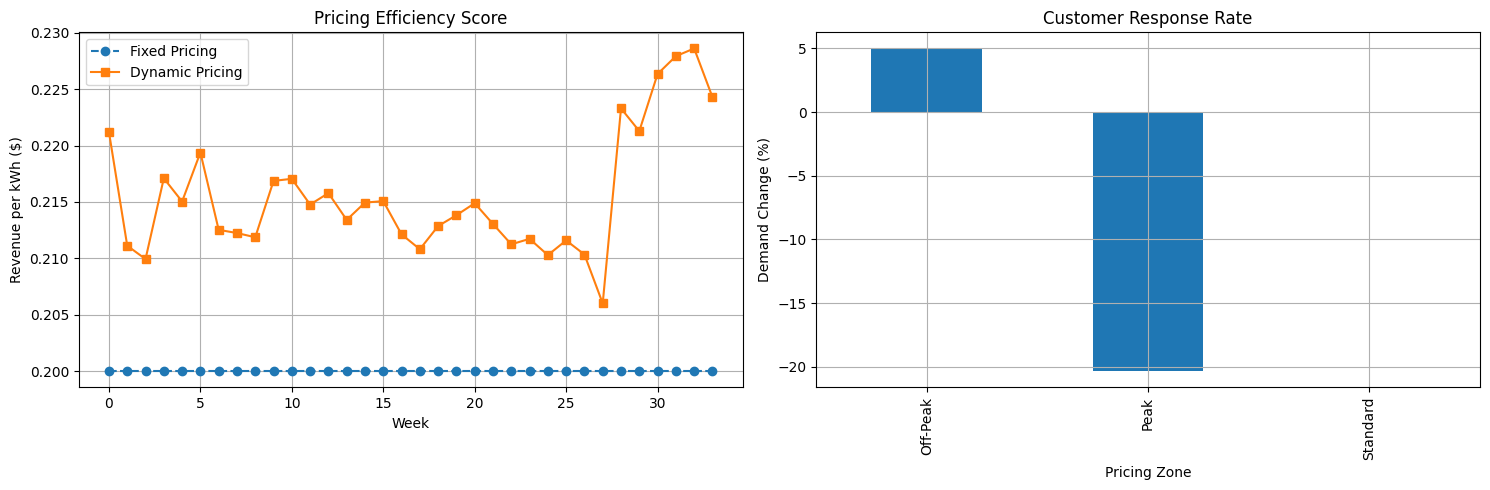


Pricing Efficiency Score
Fixed Pricing   : $0.2000 per kWh
Dynamic Pricing : $0.2155 per kWh
Improvement     : +7.8%


In [ ]:
df['week'] = pd.to_datetime(
    df['connectionTime']
).dt.to_period('W')

weekly = df.groupby('week').agg(
    total_kwh=('kWhDelivered', 'sum'),
    fixed_rev=('fixed_revenue', 'sum'),
    dynamic_rev=('dynamic_revenue', 'sum')
).reset_index()

weekly['eff_fixed'] = (
    weekly['fixed_rev'] / weekly['total_kwh']
)

weekly['eff_dynamic'] = (
    weekly['dynamic_rev'] / weekly['total_kwh']
)

fig, axes = plt.subplots(1, 2, figsize=(15,5))


# Pricing Efficiency Score


axes[0].plot(
    weekly.index,
    weekly['eff_fixed'],
    marker='o',
    linestyle='--',
    label='Fixed Pricing'
)

axes[0].plot(
    weekly.index,
    weekly['eff_dynamic'],
    marker='s',
    label='Dynamic Pricing'
)

axes[0].set_title(
    "Pricing Efficiency Score"
)

axes[0].set_xlabel(
    "Week"
)

axes[0].set_ylabel(
    "Revenue per kWh ($)"
)

axes[0].legend()

axes[0].grid(True)


# Customer Response Rate


response['Customer_Response_Rate'].plot(
    kind='bar',
    ax=axes[1]
)

axes[1].set_title(
    "Customer Response Rate"
)

axes[1].set_xlabel(
    "Pricing Zone"
)

axes[1].set_ylabel(
    "Demand Change (%)"
)

axes[1].grid(True)

plt.tight_layout()
plt.show()


# Summary


avg_fixed = weekly['eff_fixed'].mean()
avg_dynamic = weekly['eff_dynamic'].mean()

print("\nPricing Efficiency Score")

print(
    f"Fixed Pricing   : ${avg_fixed:.4f} per kWh"
)

print(
    f"Dynamic Pricing : ${avg_dynamic:.4f} per kWh"
)

print(
    f"Improvement     : {((avg_dynamic-avg_fixed)/avg_fixed)*100:+.1f}%"
)

---
## 💾 Section 12 — Save Final Processed Dataset

> Saving the final enriched dataset (with all engineered features, dynamic pricing, and revenue columns) to `/kaggle/working/` for submission.

In [ ]:
df.to_csv(
    "/kaggle/working/final_processed_ev_data.csv",
    index=False
)

print("\nFinal Processed Dataset Saved Successfully")


Final Processed Dataset Saved Successfully


---
## ✅ Project Summary & Key Findings

<div style="background: #f0fdf4; border-left: 5px solid #40916c; padding: 20px 24px; border-radius: 0 8px 8px 0; margin: 10px 0;">

### 📌 What We Did
1. **Loaded & cleaned** ACN and UrbanEV charging datasets
2. **Engineered features** + congestion probability output — hour, day, duration, weekend flag, utilization rate
3. **Explored demand patterns** — identified peak hours, weekend differences, heatmap insights
4. **Trained a Random Forest** model to predict charging demand (kWh)
5. **Built a dynamic pricing engine** with surge/discount rules + Off-Peak Uplift % measurement with surge and discount rules
6. **Measured revenue impact**, Customer Response Rate, and Pricing Efficiency Score (Monitoring Agent) — dynamic pricing vs flat-rate baseline

</div>

---

### ⚠️ Assumptions & Limitations

- Fixed baseline price of **$0.20/kWh** used for comparison — real grid costs vary
- Price elasticity of demand **not modeled** — real demand response to pricing changes would require A/B test data
- **No causal claims** — we identify patterns, not causes
- Dataset is from **Caltech, California**
- **Waiting Time Reduction** measured using peak demand reduction as a proxy metric
- Results depend on ACN and UrbanEV datasets
---

*📘 Open Project 2026 — Society of Business*